<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

---

### ScalarImage

>      ScalarImage (*args, **kwargs)

Image whose pixel values represent scalars.

See :class:`~torchio.Image` for more information.

## Image Writers

In [0]:
#| echo: false
#| output: asis
show_doc(write_image)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L25){target="_blank" style="float:right; font-size:smaller"}

### write_image

```python

def write_image(
    data, file_path, dimension_order:str='TCZYX'
):


```

*Writes an image to a file.*

:param data: Image data (numpy array, tensor, or AICSImage)
:param file_path: Path to save the image
:param format: Format to save the image in (default is png)

In [ ]:
# Example usage:
numpy_array = np.random.rand(3, 100, 100)
write_image(numpy_array, './data_examples/output_from_numpy.tiff')

tensor = torch.rand(3, 100, 100)
write_image(tensor, './data_examples/output_from_tensor.tiff')

aics_image = AICSImage('./data_examples/example_tiff.tiff')
write_image(aics_image, './data_examples/output_from_tiff.png')

Attempted file (/home/biagio/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/biagio/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


Image successfully saved to ./data_examples/output_from_numpy.tiff
Image successfully saved to ./data_examples/output_from_tensor.tiff
Image successfully saved to ./data_examples/output_from_tiff.png


## Image Readers

It uses helper functions such as _load_and_preprocess and _multi_sequence to load and preprocess biological images.

In [0]:
#| echo: false
#| output: asis
show_doc(tiff2torch)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L50){target="_blank" style="float:right; font-size:smaller"}

### tiff2torch

```python

def tiff2torch(
    file_path:str
):


```

*Load tiff into pytorch tensor*

In [0]:
#| echo: false
#| output: asis
show_doc(string2dict)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L60){target="_blank" style="float:right; font-size:smaller"}

### string2dict

```python

def string2dict(
    input_string:str
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(split_path)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L83){target="_blank" style="float:right; font-size:smaller"}

### split_path

```python

def split_path(
    file_path, # The path to the file to split
    exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.ome.tiff', '.tiff', '.tif', '.png'], # List of filename extensions
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(aics_image_reader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L98){target="_blank" style="float:right; font-size:smaller"}

### aics_image_reader

```python

def aics_image_reader(
    ind_dict:NoneType=None, # Dictionary indicating the channels to load
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

In [ ]:
file_path = 'data_examples/example_tiff.tiff'
test_img, _ = aics_image_reader({'Z': 0})(file_path)
test_eq(test_img.shape, (1, 1, 512, 512))

### Hierarchical Data Format

In [0]:
#| echo: false
#| output: asis
show_doc(split_hdf_path)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L162){target="_blank" style="float:right; font-size:smaller"}

### split_hdf_path

```python

def split_hdf_path(
    file_path, # The path to the HDF5 file to split
    hdf5_exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.h5', '.hdf5'], # List of filename extensions
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(hdf5_reader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L178){target="_blank" style="float:right; font-size:smaller"}

### hdf5_reader

```python

def hdf5_reader(
    dataset:NoneType=None, # The dataset to load
    patch:int=0, # The patch to load from the dataset
    hdf5_exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.h5', '.hdf5'], # List of filename extensions
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

Images can be loaded by explicitly writing dataset name and path number...

In [ ]:
from bioMONAI.visualize import plot_image

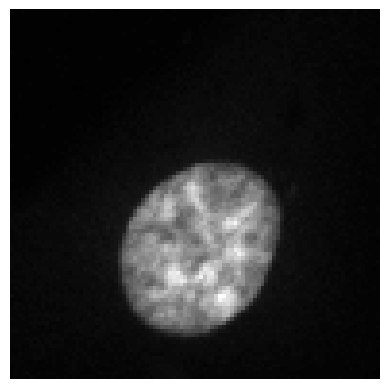

In [ ]:
file_path = './data_examples/0450_1.hdf5'
dataset_name='clean'
patch_num=10

im , _ = hdf5_reader(dataset=dataset_name, patch=patch_num)(file_path)
plot_image(im[0])

... or enconding them in the path, where datasets are subfolders and patches the image files. The latter being compatible with [`image_reader`](https://deepCLEM.github.io/bioMONAI/io.html#image_reader) syntaxis.

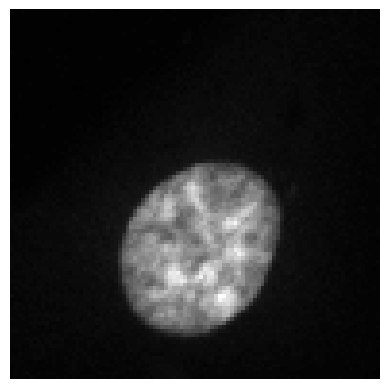

In [ ]:
f = file_path + '/' + dataset_name + '/' + '%d'%(patch_num)
im , _ = hdf5_reader()(f)
plot_image(im[0])

### Preprocessing

### Load and preprocess

In [ ]:
org_img, _, _ = _load_and_preprocess(f)

test_eq(org_img.data[0].shape, im.shape)

### Read multichannel data

In [ ]:
t = _multi_sequence([f], only_tensor=True);
test_eq(t[0].shape, im.shape)

In [ ]:
t.shape

torch.Size([1, 1, 96, 96])

### Image reader

In [0]:
#| echo: false
#| output: asis
show_doc(image_reader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L337){target="_blank" style="float:right; font-size:smaller"}

### image_reader

```python

def image_reader(
    file_path:(<class 'str'>, <class 'pathlib.Path'>, <class 'fastcore.foundation.L'>, <class 'list'>), # Path to the image
    dtype:_TensorMeta=Tensor, # Datatype for the return value. Defaults to torchTensor
    only_tensor:bool=True, # To return only an image tensor
    kwargs:VAR_KEYWORD
):


```

*Loads and preprocesses a medical image.*

Args:
    file_path: Path to the image. Can be a string, Path object or a list.
    dtype: Datatype for the return value. Defaults to torchTensor.
    reorder: Whether to reorder the data to be closest to canonical 
        (RAS+) orientation. Defaults to False.
    resample: Whether to resample image to different voxel sizes and 
        image dimensions. Defaults to None.
    only_tensor: To return only an image tensor. Defaults to True.

Returns:
    The preprocessed image. Returns only the image tensor if 
    only_tensor is True, otherwise returns original image, 
    preprocessed image, and original size.

In [ ]:
test_eq(image_reader(f)[0].shape, im.shape)